# XGBoost — Customer Churn Prediction (Telco)

Gradient-boosted trees. Where the Random Forest builds hundreds of independent
trees and averages them (bagging, which reduces **variance**), boosting grows
trees sequentially, each one fitting the residual errors of the ensemble so far
(which reduces **bias**).

That difference has a practical consequence visible in the search space below:
adding trees to a forest is safe, but adding trees to a boosted model eventually
overfits. Boosting therefore needs far more regularisation, and `n_estimators`
and `learning_rate` have to be tuned together.

The protocol is identical to the other notebooks so the numbers are comparable:

1. **Preprocessing** — feature selection, feature engineering, encoding.
2. **Model definition** — a factory that builds the estimator from a parameter dict.
3. **Search space** — which hyper-parameters Optuna is allowed to move.
4. **Objective function** — mean out-of-fold average precision across 5 folds.
5. **Study** — the actual search.
6. **Threshold selection** — chosen on out-of-fold probabilities, never on test.
7. **Final training** — refit on the whole training set.
8. **Evaluation** — held-out test set.

This notebook is self-contained: it does not import anything from `src/`.

## 1. Imports and global settings

The XGBoost version is printed because the GPU switch moved between major
releases, and getting it wrong fails **silently** rather than loudly:

- **2.0 and later**: `tree_method="hist"` plus `device="cuda"`.
- **1.x**: there is no `device` parameter at all. Passing it is accepted and
  ignored with a warning, and training stays on the CPU. GPU there means
  `tree_method="gpu_hist"`.

This notebook runs on CPU so it works anywhere; the cell below tells you what to
change if you have a GPU.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import xgboost
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
)
from xgboost import XGBClassifier

SEED = 42
N_SPLITS = 5
N_TRIALS = 50
TEST_SIZE = 0.2

np.random.seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

XGB_MAJOR = int(xgboost.__version__.split(".")[0])
print(f"pandas {pd.__version__}")
print(f"xgboost {xgboost.__version__}")
print(
    "For GPU use: "
    + (
        'tree_method="hist", device="cuda"'
        if XGB_MAJOR >= 2
        else 'tree_method="gpu_hist"  (this version has no "device" parameter)'
    )
)


/home/alejandropenagos/Escritorio/Alejandro/Machine Learning/customer-churn-prediction/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pandas 3.0.6
xgboost 1.7.6
For GPU use: tree_method="gpu_hist"  (this version has no "device" parameter)


## 2. Load and preprocess the dataset

The full pipeline (feature selection, service engineering, cleaning,
encoding, train/test split and standardisation) lives in
`PreprocessingTelco`, so the notebook only consumes the ready-to-model
splits.


In [2]:
from pathlib import Path
import sys

for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / "w1_supervized_learning").is_dir():
        sys.path.insert(0, str(parent))
        break
else:
    raise ModuleNotFoundError("Could not locate the src directory")

from w1_supervized_learning.data_preprocessing.data_preprocessing_telco import (
    PreprocessingTelco,
)


prep = PreprocessingTelco()
X_train, X_test, y_train, y_test = prep.preprocess()
FEATURE_NAMES = prep.feature_names

y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

WEIGHT_RATIO = float((y_train == 0).sum() / (y_train == 1).sum())

print(f"Train: {X_train.shape}  churn rate {y_train.mean():.1%}")
print(f"Test:  {X_test.shape}  churn rate {y_test.mean():.1%}")
print(f"Negative/positive ratio in train: {WEIGHT_RATIO:.2f}")


Train: (5625, 22)  churn rate 26.6%
Test:  (1407, 22)  churn rate 26.6%
Negative/positive ratio in train: 2.76


## 3. Model definition

A factory rather than a single instance, because the search needs a *fresh*
untrained model on every fold of every trial.

The fixed settings:

- **`objective="binary:logistic"`** — binary classification with log-loss, which
  makes `predict_proba` return calibrated-ish probabilities rather than raw scores.
- **`eval_metric="logloss"`** — set explicitly to silence a version-dependent
  default warning; it does not affect training here since no early stopping is used.
- **`tree_method="hist"`** — buckets continuous features into histograms instead of
  evaluating every possible split point. Much faster, with no meaningful loss in
  quality at this dataset size.
- **`n_jobs=-1`** — parallelise split finding across cores.

In [3]:
def build_model(params: dict) -> XGBClassifier:
    """Return an unfitted XGBoost classifier with the given hyper-parameters."""
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1,
        **params,
    )


build_model({"n_estimators": 200, "learning_rate": 0.1, "max_depth": 4})

,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'
,feature_types,None
,gamma,None


## 4. Hyper-parameter search space

Boosting has many more knobs than a forest because every one of them fights
overfitting from a different angle.

**Capacity and step size**
- `n_estimators` and `learning_rate` trade off against each other: many small
  steps or few large ones. They must be searched jointly, which is exactly what a
  sampler like TPE is good at.
- `max_depth` is kept to 3–8. Deep trees in a boosted ensemble overfit fast; the
  ensemble gets its expressiveness from *many* shallow trees, not from deep ones.

**Split constraints**
- `min_child_weight` — minimum summed instance weight in a leaf.
- `gamma` — minimum loss reduction required to accept a split. Effectively prunes.

**Stochasticity** (the part borrowed from bagging)
- `subsample` — fraction of rows per tree.
- `colsample_bytree` — fraction of features per tree.

**Explicit regularisation**
- `reg_alpha` (L1) and `reg_lambda` (L2) on the leaf weights, both sampled on a
  log scale since their useful range spans orders of magnitude.

**Imbalance**
- `scale_pos_weight` multiplies the gradient of the positive class. Its upper
  bound is derived from the dataset's own ratio (`WEIGHT_RATIO`) rather than
  hard-coded, so the same space transfers to the Telecom dataset unchanged.

In [4]:
UPPER_POS_WEIGHT = max(WEIGHT_RATIO * 2.0, 1.5)


def suggest_params(trial: optuna.Trial) -> dict:
    """Sample one hyper-parameter configuration."""
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-3, 5.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 20.0, log=True),
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight", 1.0, UPPER_POS_WEIGHT, log=True
        ),
    }


print(f"scale_pos_weight will be searched in [1.0, {UPPER_POS_WEIGHT:.2f}]")

scale_pos_weight will be searched in [1.0, 5.53]


## 5. Objective function

**Why average precision and not accuracy or F1?**

Accuracy is useless here: predicting "nobody churns" already scores ~73%. F1 and
accuracy also depend on a decision threshold, which is not tuned yet at this
stage — optimising them would entangle two separate decisions. Average precision
summarises the whole precision-recall curve, so it measures how well the model
*ranks* customers by churn risk, independently of where the cut lands.

Note that this is deliberately **not** the same as the `eval_metric` passed to
XGBoost. Log-loss is what gradient boosting optimises internally, tree by tree;
average precision is what *we* use to compare whole configurations.

**Why report fold by fold?** `trial.report` plus `should_prune` lets Optuna's
`MedianPruner` abandon a clearly bad configuration after 2 or 3 folds instead of
paying for all 5.

In [5]:
def objective(trial: optuna.Trial) -> float:
    """Mean out-of-fold average precision for one hyper-parameter configuration."""
    params = suggest_params(trial)
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    scores: list[float] = []

    for step, (fold_train_idx, fold_valid_idx) in enumerate(cv.split(X_train, y_train)):
        model = build_model(params)
        model.fit(X_train[fold_train_idx], y_train[fold_train_idx])

        proba = model.predict_proba(X_train[fold_valid_idx])[:, 1]
        scores.append(average_precision_score(y_train[fold_valid_idx], proba))

        trial.report(float(np.mean(scores)), step)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(scores))

## 6. Run the study

`TPESampler` builds a probabilistic model of which regions of the space produced
good scores and samples from there. With ten hyper-parameters this matters much
more than it did for the linear model: a grid search over this space is infeasible
and a random search would waste most of its budget.

`MedianPruner(n_warmup_steps=1)` only starts pruning after the first fold, so no
trial is killed on a single unlucky fold.

Lower `N_TRIALS` in section 1 if you just want to check that the pipeline runs
end to end.

In [6]:
study = optuna.create_study(
    study_name="xgboost_telco",
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = dict(study.best_params)

print(f"Best CV average precision: {study.best_value:.4f}")
print("Best hyper-parameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

completed = [t for t in study.trials if t.state.name == "COMPLETE"]
pruned = [t for t in study.trials if t.state.name == "PRUNED"]
print(f"\nTrials: {len(completed)} completed, {len(pruned)} pruned")

Best trial: 43. Best value: 0.669072: 100%|██████████| 50/50 [00:26<00:00,  1.89it/s]

Best CV average precision: 0.6691
Best hyper-parameters:
  n_estimators: 400
  learning_rate: 0.015455817301175864
  max_depth: 3
  min_child_weight: 1
  subsample: 0.6460761356100594
  colsample_bytree: 0.673957593117277
  gamma: 1.0395040292222562
  reg_alpha: 0.0017477203545222832
  reg_lambda: 0.02681390111758258
  scale_pos_weight: 1.576810829444838

Trials: 43 completed, 7 pruned


## 7. Search diagnostics

Two things worth reporting for a ten-dimensional space.

**Optimisation history** — if the best score is still climbing at the end, the
budget was too small and more trials would still pay off. If it plateaued early,
the space is likely saturated.

**Parameter importance** — Optuna estimates how much of the objective's variance
each parameter explains. With this many knobs it usually turns out that two or
three dominate and the rest are noise, which is useful guidance for the report.

TypeError: 'Axes' object is not subscriptable

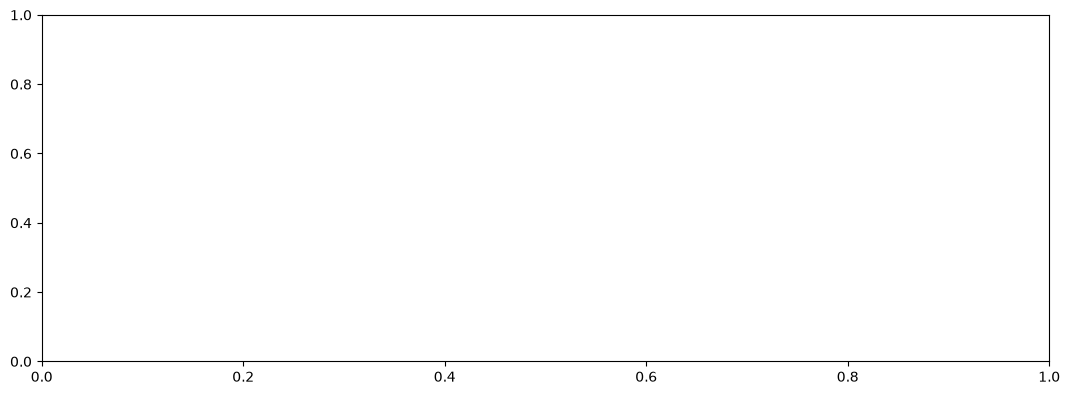

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

trial_numbers = [t.number for t in completed]
trial_values = [t.value for t in completed]
running_best = np.maximum.accumulate(trial_values) if trial_values else []

axes[0].scatter(trial_numbers, trial_values, s=18, alpha=0.6, label="trial")
axes[0].plot(trial_numbers, running_best, color="crimson", label="best so far")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("CV average precision")
axes[0].set_title("Optimisation history")
axes[0].legend()
axes[0].grid(alpha=0.3)

if len(completed) >= 10:
    evaluator = optuna.importance.MeanDecreaseImpurityImportanceEvaluator()

    importance = optuna.importance.get_param_importances(
        study,
        evaluator=evaluator
    )

    importance_series = (
        pd.Series(importance, name="importance")
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(
        importance_series.index,
        importance_series.values,
        color="steelblue"
    )
    ax.set_xlabel("Importance")
    ax.set_title("Hyper-parameter importance")
    ax.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()
else:
    print(
        f"Only {len(completed)} completed trials; "
        "skipping importance estimate."
    )
plt.tight_layout()
plt.show()

## 8. Threshold selection on out-of-fold probabilities

`predict_proba` returns a probability; turning it into a decision needs a cut. The
default 0.5 is arbitrary and usually wrong on imbalanced data.

There is an extra wrinkle here: `scale_pos_weight` already shifts the model's
probability estimates upwards to compensate the imbalance. The tuned threshold and
`scale_pos_weight` therefore interact, which is a further reason not to leave the
cut at its default.

The cut is chosen on **out-of-fold** predictions from `cross_val_predict`: every
probability comes from a model that did not see that row. Tuning it on the test set
would be a second, subtler form of leakage.

In [ ]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_proba = cross_val_predict(
    build_model(best_params),
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
oof_f1 = [f1_score(y_train, (oof_proba >= t).astype(int)) for t in thresholds]

best_threshold = float(thresholds[int(np.argmax(oof_f1))])
print(f"Best threshold: {best_threshold:.2f}  (OOF F1 = {max(oof_f1):.4f})")
print(f"F1 at the default 0.50: {f1_score(y_train, (oof_proba >= 0.5).astype(int)):.4f}")

## 9. How sensitive is F1 to the threshold?

A flat curve around the optimum means the choice is robust; a sharp peak means the
model is fragile and the threshold would need recalibrating in production.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, oof_f1, label="OOF F1")
ax.axvline(best_threshold, color="crimson", linestyle="--", label=f"best = {best_threshold:.2f}")
ax.axvline(0.5, color="grey", linestyle=":", label="default = 0.50")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("F1 score")
ax.set_title("XGBoost — threshold sensitivity (out-of-fold)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Final training

Hyper-parameters and threshold are now fixed, both chosen using training data
only. The model is refitted on the **entire** training set: the folds existed to
estimate quality, and holding data back from the final fit would only waste it.

In [ ]:
final_model = build_model(best_params)
final_model.fit(X_train, y_train)

booster = final_model.get_booster()
print(f"Fitted on {X_train.shape[0]} rows")
print(f"Boosting rounds: {booster.num_boosted_rounds()}")
print(f"Learning rate: {best_params['learning_rate']:.4f}")
print(f"Max depth: {best_params['max_depth']}")

## 11. Evaluation on the test set

The test set is touched exactly once, here.

Metrics are ordered from most to least informative for this problem.
`average_precision` and `roc_auc` judge the ranking and are threshold-free;
`f1`, `recall` and `precision` judge the decisions at the chosen cut.
**`accuracy` is last on purpose** — a model predicting "no churn" for everyone
scores ~73% here.

In [ ]:
test_proba = final_model.predict_proba(X_test)[:, 1]
test_preds = (test_proba >= best_threshold).astype(int)

metrics = {
    "average_precision": average_precision_score(y_test, test_proba),
    "roc_auc": roc_auc_score(y_test, test_proba),
    "f1": f1_score(y_test, test_preds),
    "recall": recall_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds),
    "balanced_accuracy": balanced_accuracy_score(y_test, test_preds),
    "accuracy": accuracy_score(y_test, test_preds),
}

print(f"Threshold used: {best_threshold:.2f}\n")
pd.Series(metrics, name="xgboost").to_frame().round(4)

## 12. Confusion matrix

The business reading of the two error types:

- **False negatives** — churners the model missed. Direct lost revenue.
- **False positives** — loyal customers flagged as at-risk. Cost of a wasted
  retention offer.

Which one hurts more depends on the margin per customer versus the cost of the
offer, and that is exactly the trade-off the threshold controls.

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()

pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["actual: stays", "actual: churns"],
    columns=["predicted: stays", "predicted: churns"],
)

## 13. Feature importance by gain

XGBoost exposes several importance types. **Gain** is the informative one: the
average improvement in the loss brought by splits on that feature. The default
`feature_importances_` attribute uses it.

This is more meaningful than the forest's impurity importance because it is
measured in units of the actual objective being optimised. It shares one caveat
though: it is computed on training data, so it cannot distinguish a genuinely
predictive feature from one the model used to fit noise.

As with the forest, these values have **no sign**: they say a feature matters, not
in which direction. For signed, per-prediction attributions, SHAP values are the
standard tool and integrate directly with XGBoost.

In [ ]:
importances = (
    pd.Series(final_model.feature_importances_, index=FEATURE_NAMES, name="gain")
    .sort_values(ascending=False)
)

top = importances.head(15)[::-1]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top.index, top.values, color="darkorange")
ax.set_xlabel("Importance (gain)")
ax.set_title("Top 15 features by gain")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

importances.head(10).to_frame().round(4)

## 14. Notes and limitations

**What this notebook establishes.** A tuned boosting ensemble under the same
protocol as the other models, so differences in `average_precision` are
attributable to the model rather than the evaluation setup.

**Limitations to keep in mind when comparing notebooks.**

- `n_estimators` is tuned instead of using `early_stopping_rounds`. Early stopping
  is usually the better practice for boosting, but it needs a validation split
  *inside* each fold, which would make this notebook's protocol differ from the
  other three. Tuning the number of rounds keeps the comparison clean at some cost
  in compute.
- Ten hyper-parameters on ~5600 training rows is a large space for a small
  dataset. Part of the gain over the forest may be search effort rather than model
  capacity — worth acknowledging explicitly in the report.
- The threshold is tuned for F1. A different operating point would change the
  decision metrics without changing `average_precision` or `roc_auc`.
- A single train/test split gives a point estimate. Repeating with several seeds
  would put error bars on these numbers.

**To run this on the Telecom dataset**, replace the loading and encoding cells
with that dataset's schema (`churn` as the target, `telecom_partner`/`state`/
`city` one-hot encoded, `date_of_registration` split into year and month).
Everything from section 7 onwards works unchanged. With ~243k rows, XGBoost with
`tree_method="hist"` scales well, but consider lowering `N_TRIALS`.